# Using the BOFEK soil dataprovider for The Netherlands

The Python Crop Simulation Environment ([PCSE](https://pcse.readthedocs.io)) provides standardized tools for defining and collecting input for weather, crop parameters and agromanagement. However, gathering soil information for crop models is still complicated because there were no tools and databases available to obtain it. For the Dutch situation the [BOFEK soil database](https://www.wur.nl/nl/onderzoek/producten-diensten/bodemfysische-eenhedenkaart-bofek2020) is available and we developed a dataprovider that can pull soil information from BOFEK and formats it for the use with the [classic waterbalance](https://pcse.readthedocs.io/en/stable/code.html#pcse.soil.WaterbalanceFD) (models coded with `CWB`). 

This dataprovider will be extended for the multi-layered soil waterbalance and SNOMIN, but this has not been implemented yet.

Allard de Wit, Herman Berghuijs

September 2026

## Requirements for running this notebook

There are several packages needed for this notebook (see `pyproject.toml`):
- `duckdb == 1.5`
- `pyproj == 3.7`
- `ipyleaflet`
- `pandas`
- `matplotlib`
- `pcse >= 6.0.13`

## Installing the pyproj dependency

Installing `pyproj` using pip or uv can be tricky because of the dependency on [PROJ](https://proj.org/en/stable/install.html#install) which is a C library. Therefore, installing the required dependencies is done most easily through a conda environment. See the Anaconda documentation on how to work with conda environments. Alternatively, you can download the package from [this site](https://github.com/cgohlke/geospatial-wheels/releases/tag/v2026.8.20) and install manually.



In [3]:
import sys
from IPython.display import HTML
import ipyleaflet
from ipyleaflet import WMSLayer, Map,LayerGroup, ScaleControl, Marker
import pandas as pd
import matplotlib.pyplot as plt

import soil_dataprovider_nl
import pcse
from pcse.models import Wofost72_WLP_CWB, Wofost72_PP, Wofost73_WLP_MLWB

print("This notebook was built with:")
print(f"python version: {sys.version}")
print(f"PCSE version: {pcse.__version__}")
print(f"SoilDataProvider version: {soil_dataprovider_nl.__version__}")

This notebook was built with:
python version: 3.14.7 | packaged by Anaconda, Inc. | (main, Aug 14 2026, 10:12:46) [MSC v.1942 64 bit (AMD64)]
PCSE version: 6.0.13
SoilDataProvider version: 1.0.0


## How CWB parameters are computed from BOFEK

BOFEK provides information about the soil characteristics for each layer over the depth of the soil. This includes the thickness of each layer and the Mualem-Vangenuchten parameters which describe the relationship between suction (pF), water content and hydraulic conductivity. However, the classic water balance uses a single soil layer, therefore the soil parameters for each layer have to be aggregated.

The following approach is used to aggregate the soil parameters:
- Wilting point for the entire profile (`SMW`) is calculated from a layer-weighted average of the wilting point of each layer, the latter is assumed at pF=4.2
- Field capacity for the entire profile (`SMFCF`) is estimated in two steps: 1) The water holding capacity is calculated for all layers which is defined as the amount of volume between wilting point and field capacity (pF=2) for each layer. `SMFCF` is than calculated as the value with an equivalent water holding capacity given the soil rootable depth (`RDMSOL`).
- `SM0` (porosity) is computed as the value required to store an equivalent volume of water given the rootable depth.
- Soil rootable depth (`RDMSOL`) is derived from the maximum soil depth or from the user-defined `max_root_depth`. The smallest of the
  two values is taken.
- The soil drainage parameters (`SOPE/KSUB`) are computed as the conductivity of the bottom layer at pF=1.

Regarding the `SOPE/kSUB` parameters, it is unclear how they have to be estimated physically. In practice, they were probably used as a calibration parameter in order to limit excessive drainage. In the classic water balance drainage occurs only when soil moisture is above field capacity (pF=2.0), therefore we estimate both parameters as the conducitivity at pF=1.0. Moreover, since drainage happens mostly in the lower soil layers, we use the MvG parameters of the bottom layer to estimate the conductivity.  

## Example of soil parameters near Wageningen Campus

North of Wageningen Campus there are fields that are being used for experiments on crops. These fields are located on a sandy shallow ridge. The marker in the map below shows the location of those fields and the orange color shows the sandy ridge. The soil map is read from the WMS service provided by [PDOK](https://www.pdok.nl/).

Let's derive the soil parameters from BOFEK for this location.

In [4]:
# 1. Create the map centered north of Wageningen Campus in lon/lat
longitude = 5.6597
latitude = 51.9894
center = (latitude,longitude)
m = Map(center=center, zoom=14)

bodem = WMSLayer(
    url="https://service.pdok.nl/bzk/bro-bodemkaart/wms/v1_0",
    layers="soilarea",          # <-- the actual layer name
    format="image/png",
    transparent=True,
    # opacity=0.7,
    # attribution="PDOK / BRO",
    tiled=True,
    crs=ipyleaflet.projections.EPSG3857
)
point = Marker(location=center, draggable=False)
m.add_layer(bodem)
m.add(point)
m

Map(center=[51.9894, 5.6597], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoo…

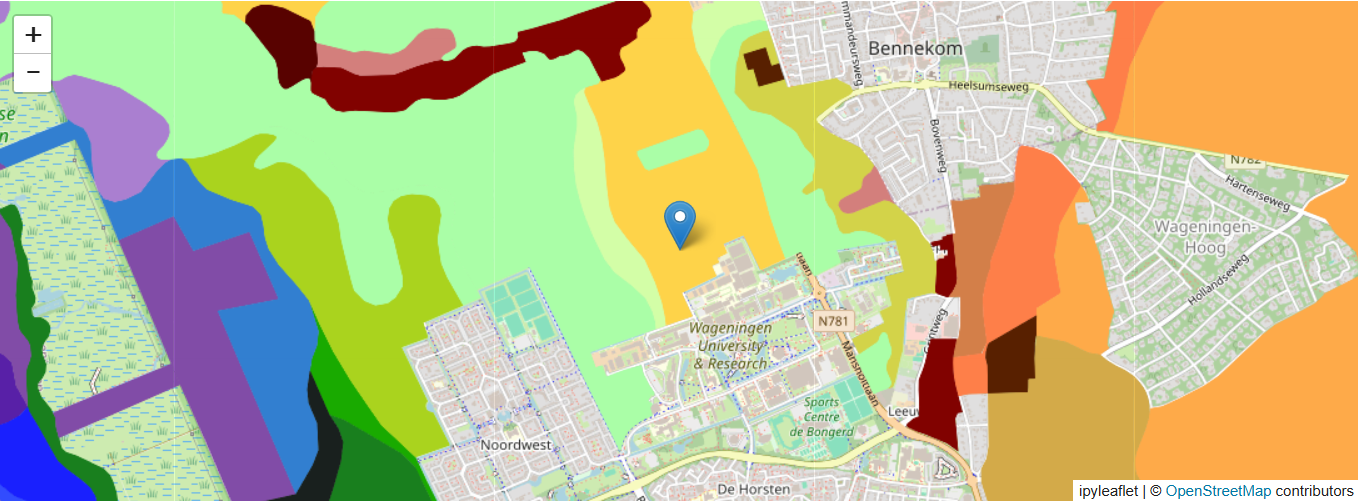

## Using the soil data provider

The soil data provider can be used in two different ways. 

### 1. Use the model as an argument
First of all, you can import the generic data provider `SoilDataProviderNL` from the package and feed the PCSE model as the first argument to the dataprovider. Next the coordinates of the location must be provided either in longitude/latitude or in Dutch RD coordinates. The dataprovider will recognize the input coordinates automatically. 

In [7]:
from soil_dataprovider_nl import SoilDataProviderNL
soild_sand = SoilDataProviderNL(Wofost72_WLP_CWB, xcoord=longitude, ycoord=latitude)

Found soil DB at C:\Users\wit015\AppData\Local\Temp\bofek_soil_nl.ddb


Because the model `Wofost72_WLP_CWB` is tagged with `CWB`, the `SoilDataProviderNL` will recognize it and automatically use the correct dataprovider. 

### 2. Import the correct data provider manually

Alternatively, you can explicitly import the CWB soil data provider and use it by only providing coordinates:

In [8]:
from soil_dataprovider_nl import SoilDataProviderNL_CWB
soild_sand = SoilDataProviderNL_CWB(xcoord=longitude, ycoord=latitude)

Found soil DB at C:\Users\wit015\AppData\Local\Temp\bofek_soil_nl.ddb


Feeding a model that uses the multi-layer soil water balance (e.g. tagged with `MLWB`) raises a NotImplementedError as the dataprovider is not yet implemented.

In [9]:
try:
    SoilDataProviderNL(Wofost73_WLP_MLWB, xcoord=longitude, ycoord=latitude)
except NotImplementedError as e:
    print(e)

Soil dataprovider for the multi-layer waterbalance not yet implemented.


When looking at the soil characteristics found, it is obvious that this belongs to a sandy soil profile. The percentages of sand in the profile range from 88% to 92% and also they have very high drainage values of ~16 cm/day.

In [10]:
print(soild_sand)

Soil properties for location at X/Y: 173685/444484 - lon/lat: 5.660/51.989
Soil rootable depth estimated at 120 cm (from maximum soil profile depth)
Soil profile characteristics:
 thickness  pclay  psilt  psand      SMW    SMFCF      SM0
        25   0.04   0.08   0.88 0.074022 0.312391 0.433851
        25   0.03   0.09   0.88 0.040080 0.269736 0.387057
        70   0.02   0.06   0.92 0.010571 0.184627 0.365847
Actual CWB parameter values:
- SMW: 0.030 [-]
- SMFCF: 0.229 [-]
- SM0: 0.384 [-]
- CRAIRC: 0.078 [-]
- RDMSOL: 120.000 [cm]
- SOPE: 16.891 [cm day-1]
- KSUB: 16.891 [cm day-1]



## Example of soil parameters near Heteren

To the south of Wageningen, the Rhine river has created deposits of heavy clay. So let's see the soil properties for this location.

In [11]:
# 1. Create the map centered west of Heteren
longitude = 5.733
latitude = 51.953
center = (latitude,longitude)
m = Map(center=center, zoom=13)

bodem = WMSLayer(
    url="https://service.pdok.nl/bzk/bro-bodemkaart/wms/v1_0",
    layers="soilarea",
    format="image/png",
    transparent=True,
    # opacity=0.7,
    # attribution="PDOK / BRO",
    tiled=True,
    crs=ipyleaflet.projections.EPSG3857
)
point = Marker(location=center, draggable=False)
m.add_layer(bodem)
m.add(point)
m

Map(center=[51.953, 5.733], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

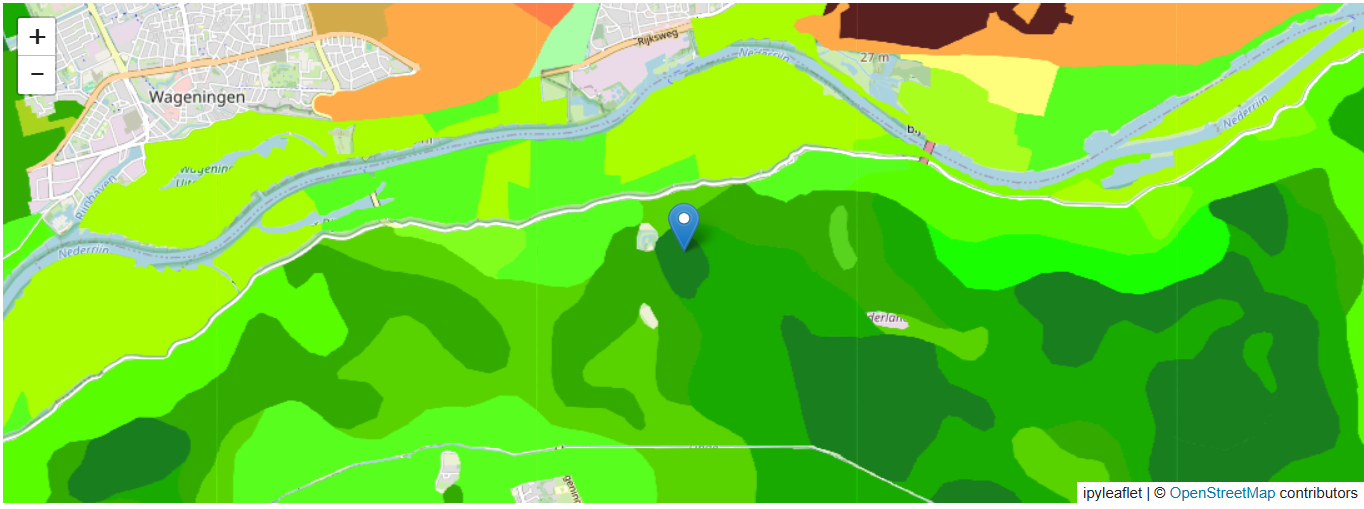

In [12]:
soild_clay = SoilDataProviderNL(Wofost72_WLP_CWB, xcoord=longitude, ycoord=latitude)
print(soild_clay)

Found soil DB at C:\Users\wit015\AppData\Local\Temp\bofek_soil_nl.ddb
Soil properties for location at X/Y: 178738/440456 - lon/lat: 5.733/51.953
Soil rootable depth estimated at 120 cm (from maximum soil profile depth)
Soil profile characteristics:
 thickness  pclay  psilt  psand      SMW    SMFCF      SM0
         8   0.50   0.43   0.07 0.323594 0.488063 0.529709
         7   0.50   0.43   0.07 0.323594 0.488063 0.529709
        35   0.55   0.42   0.03 0.356104 0.518110 0.573195
        70   0.55   0.42   0.03 0.356104 0.518110 0.573195
Actual CWB parameter values:
- SMW: 0.352 [-]
- SMFCF: 0.514 [-]
- SM0: 0.568 [-]
- CRAIRC: 0.027 [-]
- RDMSOL: 120.000 [cm]
- SOPE: 0.135 [cm day-1]
- KSUB: 0.135 [cm day-1]



The difference in soil type is clearly recognizable in the parameter that are derived: the percentages of sand are very low in the different layers, while the silt and clay dominate the profile. Also the estimated drainage values (SOPE/KSUB) are very low.

## Manually limiting the soil rootable depth

In certain cases, it is known that the soil rootable depth is limited, for example due to soil compation as a result of heavy machinery. This is not reflected in the BOFEK soil database, but can be forced manually with the `max_root_depth` parameter. In such case the water balance parameters will be recalculated using on the layers that are rootable by the crop. Note that `max_root_depth >= 20` otherwise an error will be thrown.

In [13]:
soild_clay = SoilDataProviderNL(Wofost72_WLP_CWB, xcoord=longitude, ycoord=latitude, max_root_depth=60)
print(soild_clay)

Found soil DB at C:\Users\wit015\AppData\Local\Temp\bofek_soil_nl.ddb
Soil properties for location at X/Y: 178738/440456 - lon/lat: 5.733/51.953
Soil rootable depth estimated at 60 cm (forced by `max_root_depth` parameter)
Soil profile characteristics:
 thickness  pclay  psilt  psand      SMW    SMFCF      SM0
         8   0.50   0.43   0.07 0.323594 0.488063 0.529709
         7   0.50   0.43   0.07 0.323594 0.488063 0.529709
        35   0.55   0.42   0.03 0.356104 0.518110 0.573195
        10   0.55   0.42   0.03 0.356104 0.518110 0.573195
Actual CWB parameter values:
- SMW: 0.348 [-]
- SMFCF: 0.511 [-]
- SM0: 0.562 [-]
- CRAIRC: 0.026 [-]
- RDMSOL: 60.000 [cm]
- SOPE: 0.135 [cm day-1]
- KSUB: 0.135 [cm day-1]



## Demonstrating the impact on crop simulation

In the example below we will have a look at the impact on the simulation results for the drought in the summer of 2018.

In [14]:
# Define weather data
from pcse.input import NASAPowerWeatherDataProvider
wdp = NASAPowerWeatherDataProvider(latitude=latitude, longitude=longitude)

# Define agromanagement data
import yaml
agro = yaml.safe_load("""
- 2017-10-01:
    CropCalendar:
        crop_name: potato
        variety_name: Fontane
        crop_start_date: 2018-04-15
        crop_start_type: sowing
        crop_end_date: 2018-10-15
        crop_end_type: harvest
        max_duration: 
    TimedEvents:
    StateEvents:
""")
# crop parameters and site parameters
from pcse.input import YAMLCropDataProvider, WOFOST72SiteDataProvider
cropd = YAMLCropDataProvider(Wofost72_WLP_CWB)
sited = WOFOST72SiteDataProvider(WAV=5)


In [15]:
# Wrap all parameters
from pcse.base import ParameterProvider
params_sand = ParameterProvider(soildata=soild_sand, cropdata=cropd, sitedata=sited)
params_clay = ParameterProvider(soildata=soild_clay, cropdata=cropd, sitedata=sited)

### Run simulations for potential production and with sand and clay soils

In [16]:
# Potential production, soil parameters do not have an impact but have to be provided.
wofost_pot = Wofost72_PP(params_sand, wdp, agro)
wofost_pot.run_till_terminate()
df_PP = pd.DataFrame(wofost_pot.get_output()).set_index("day")
# Sandy soil
wofost_sand = Wofost72_WLP_CWB(params_sand, wdp, agro)
wofost_sand.run_till_terminate()
df_sand = pd.DataFrame(wofost_sand.get_output()).set_index("day")
# Clay soil
wofost_clay = Wofost72_WLP_CWB(params_clay, wdp, agro)
wofost_clay.run_till_terminate()
df_clay = pd.DataFrame(wofost_clay.get_output()).set_index("day")

## Analyse the results

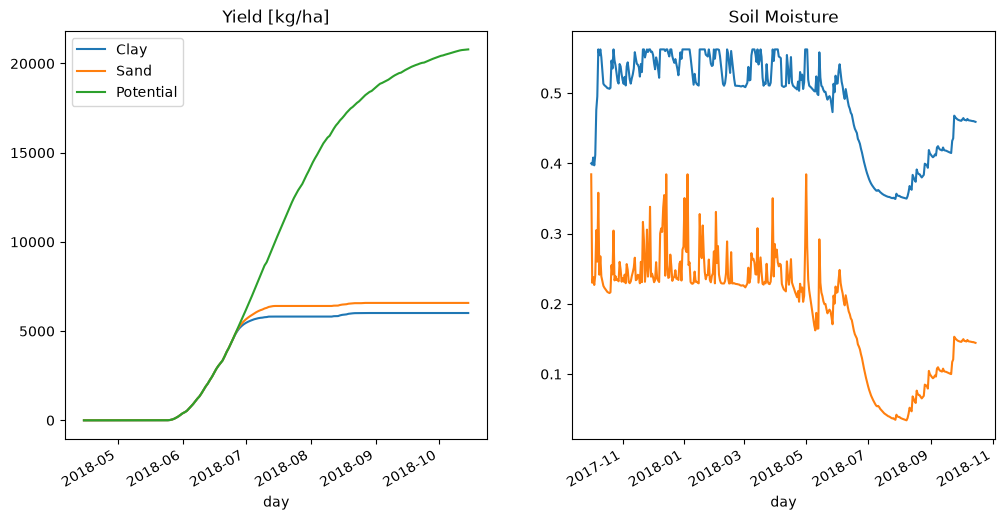

In [17]:
fig, axes = plt.subplots(ncols=2, figsize=(12,6))
ax1, ax2 = axes
df_clay.TWSO.plot(ax=ax1, label="Clay")
df_sand.TWSO.plot(ax=ax1, label="Sand")
df_clay.SM.plot(ax=ax2, label="Clay")
df_sand.SM.plot(ax=ax2, label="Sand")
df_PP.TWSO.plot(ax=ax1, label="Potential")
ax1.set_title("Yield [kg/ha]")
ax1.legend()
ax2.set_title("Soil Moisture")
fig.autofmt_xdate()


## Plotting the pF curves for the different soil layers

The SoilDataproviderNL has the option to plot the pF curves for moisture content and hydraulic conductivity. See the code example below.


In [18]:
from soil_dataprovider_nl.soil_dataprovider_nl import compute_pF_curves, plot_pF_curves
pf_results = compute_pF_curves(soild_sand.profile_characteristics)

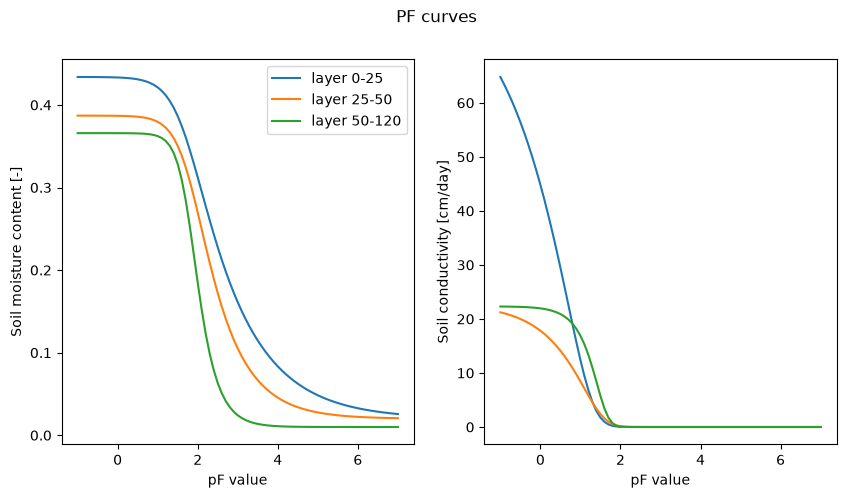

In [19]:
fig, axes = plot_pF_curves(pf_results)
fig.show()